In [1]:
import os
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score

from preprocessing.data_loader import load_all_highd
from preprocessing.features import aggregate_lane_segment, AggConfig
from preprocessing.sequences import split_by_group, LazyTrafficDataset
from models.model import LSTMTrafficMultiTask
from training.train import TrainConfig, train_multitask


In [2]:
DATA_ROOT = Path(r"D:\HighD\data")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)


In [3]:
data = load_all_highd(DATA_ROOT, n_recordings=60)
tracks_raw = data.tracks
FPS = data.fps

print("tracks:", tracks_raw.shape)
print("FPS:", FPS)


tracks: (39725708, 9)
FPS: 25.0


In [4]:
cfg = AggConfig(segment_len_m=100.0, dt_s=1.0)
agg = aggregate_lane_segment(tracks_raw, fps=FPS, cfg=cfg)

print("agg shape:", agg.shape)
agg.head()


agg shape: (50105, 8)


,tbin,laneId,segment,speed_mean,veh_count,lc_rate,density,flow
0,0,2,-1,21.215500,2,0.0,20.0,2.0
1,1,2,-1,23.720236,9,0.0,90.0,9.0
2,2,2,-1,22.105547,15,0.0,150.0,15.0
3,3,2,-1,21.712458,12,0.0,120.0,12.0
4,4,2,-1,23.796066,16,0.0,160.0,16.0


In [5]:
train_df, val_df = split_by_group(agg, train_frac=0.8, seed=SEED)
print("train groups:", train_df[["laneId","segment"]].drop_duplicates().shape[0])
print("val groups:", val_df[["laneId","segment"]].drop_duplicates().shape[0])


train groups: 35
val groups: 9


In [6]:
feature_cols = ["speed_mean", "density", "flow", "lc_rate"]

seq_len = 20   # 20 seconds history (dt=1s)
horizon = 5    # predict 5 seconds ahead
stride = 1

train_ds = LazyTrafficDataset(
    train_df, seq_len=seq_len, horizon=horizon,
    feature_cols=feature_cols,
    speed_col="speed_mean", lc_col="lc_rate",
    x_scaler=None,
    stride=stride,
    max_samples=None
)

val_ds = LazyTrafficDataset(
    val_df, seq_len=seq_len, horizon=horizon,
    feature_cols=feature_cols,
    speed_col="speed_mean", lc_col="lc_rate",
    x_scaler=train_ds.x_scaler,
    stride=stride,
    max_samples=200_000
)

print("train samples:", len(train_ds))
print("val samples:", len(val_ds))


train samples: 38438
val samples: 10611


In [7]:
model = LSTMTrafficMultiTask(input_size=len(feature_cols), hidden=128, layers=2, dropout=0.2)

tcfg = TrainConfig(
    epochs=15,
    batch_size=256,
    lr=1e-3,
    weight_decay=1e-4,
    patience=4,
    lc_weight=1.0
)

model, hist = train_multitask(model, train_ds, val_ds, cfg=tcfg, seed=SEED)


Epoch 01/15 | train_total 6.3579 | train_speed 5.8702 | train_lc 0.4877 | val MAE 1.139 RMSE 1.909 | LC prec 0.868 rec 0.910 f1 0.888 AP 0.918 | pw 1.0
Epoch 02/15 | train_total 1.6850 | train_speed 1.2994 | train_lc 0.3855 | val MAE 1.048 RMSE 1.827 | LC prec 0.867 rec 0.915 f1 0.890 AP 0.918 | pw 1.0
Epoch 03/15 | train_total 1.6697 | train_speed 1.2827 | train_lc 0.3870 | val MAE 1.121 RMSE 1.852 | LC prec 0.868 rec 0.903 f1 0.885 AP 0.918 | pw 1.0
Epoch 04/15 | train_total 1.6338 | train_speed 1.2479 | train_lc 0.3859 | val MAE 1.079 RMSE 1.791 | LC prec 0.866 rec 0.918 f1 0.891 AP 0.918 | pw 1.0
Epoch 05/15 | train_total 1.6288 | train_speed 1.2463 | train_lc 0.3825 | val MAE 0.999 RMSE 1.750 | LC prec 0.861 rec 0.923 f1 0.891 AP 0.919 | pw 1.0
Epoch 06/15 | train_total 1.6017 | train_speed 1.2210 | train_lc 0.3807 | val MAE 1.330 RMSE 1.957 | LC prec 0.866 rec 0.917 f1 0.891 AP 0.921 | pw 1.0
Epoch 07/15 | train_total 1.6202 | train_speed 1.2420 | train_lc 0.3781 | val MAE 1.097 

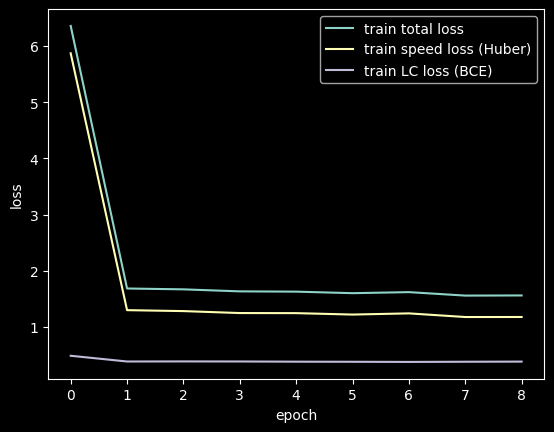

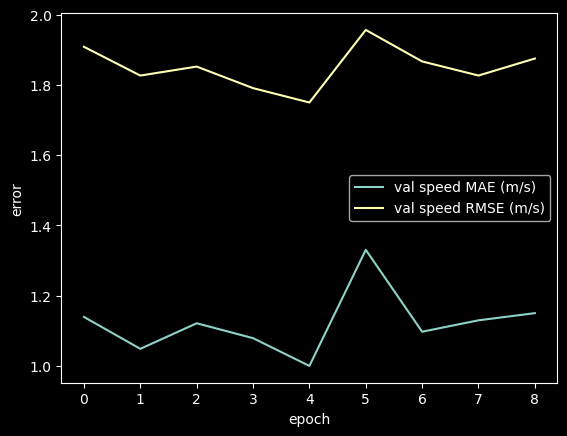

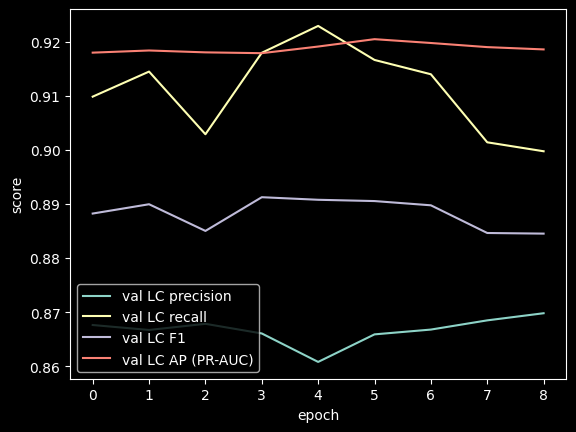

In [8]:
plt.figure()
plt.plot(hist["train_total"], label="train total loss")
plt.plot(hist["train_speed"], label="train speed loss (Huber)")
plt.plot(hist["train_lc"], label="train LC loss (BCE)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist["val_speed_mae"], label="val speed MAE (m/s)")
plt.plot(hist["val_speed_rmse"], label="val speed RMSE (m/s)")
plt.xlabel("epoch")
plt.ylabel("error")
plt.legend()
plt.show()

plt.figure()
plt.plot(hist["val_lc_prec"], label="val LC precision")
plt.plot(hist["val_lc_rec"], label="val LC recall")
plt.plot(hist["val_lc_f1"], label="val LC F1")
plt.plot(hist["val_lc_ap"], label="val LC AP (PR-AUC)")
plt.xlabel("epoch")
plt.ylabel("score")
plt.legend()
plt.show()


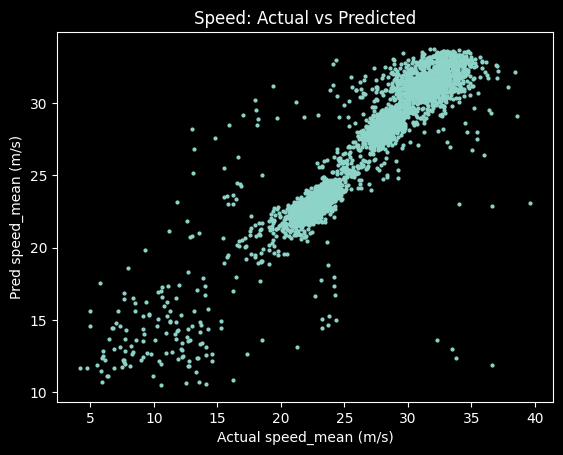

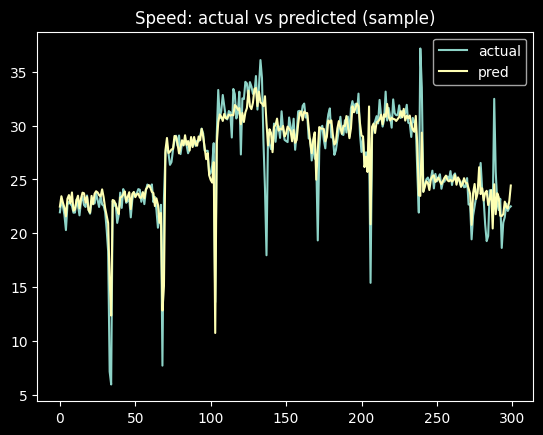

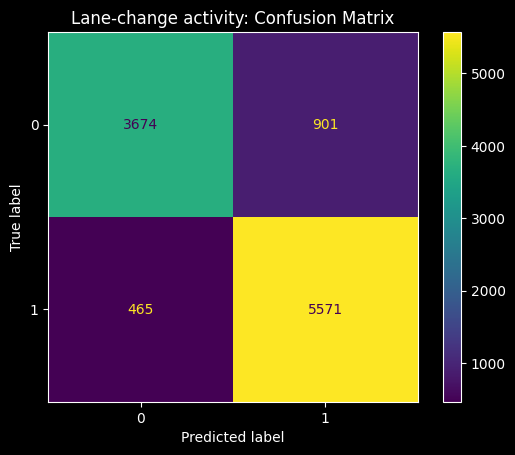

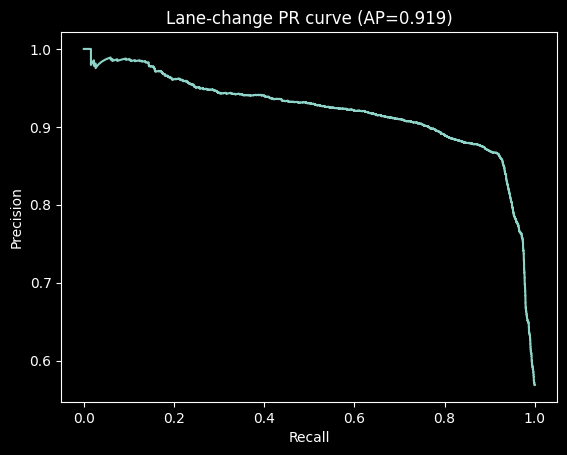

In [9]:
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
loader = DataLoader(val_ds, batch_size=512, shuffle=False)

model.eval()
ys_true, ys_pred = [], []
lc_true, lc_prob = [], []

with torch.no_grad():
    for X, y_speed, y_lc in loader:
        X = X.to(device)
        pred_speed, lc_logits = model(X)
        ys_true.append(y_speed.numpy())
        ys_pred.append(pred_speed.cpu().numpy())
        lc_true.append(y_lc.numpy())
        lc_prob.append(torch.sigmoid(lc_logits).cpu().numpy())

ys_true = np.concatenate(ys_true)
ys_pred = np.concatenate(ys_pred)
lc_true = np.concatenate(lc_true)
lc_prob = np.concatenate(lc_prob)

# Speed: scatter + sample series
plt.figure()
plt.scatter(ys_true[:5000], ys_pred[:5000], s=4)
plt.xlabel("Actual speed_mean (m/s)")
plt.ylabel("Pred speed_mean (m/s)")
plt.title("Speed: Actual vs Predicted")
plt.show()

idx = np.linspace(0, len(ys_true)-1, 300).astype(int)
plt.figure()
plt.plot(ys_true[idx], label="actual")
plt.plot(ys_pred[idx], label="pred")
plt.legend()
plt.title("Speed: actual vs predicted (sample)")
plt.show()

# Lane-change: confusion matrix + PR curve
lc_pred = (lc_prob >= 0.5).astype(int)
cm = confusion_matrix(lc_true, lc_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Lane-change activity: Confusion Matrix")
plt.show()

prec, rec, _ = precision_recall_curve(lc_true, lc_prob)
ap = average_precision_score(lc_true, lc_prob) if len(np.unique(lc_true)) > 1 else float("nan")
plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Lane-change PR curve (AP={ap:.3f})")
plt.show()


In [10]:
save_obj = {
    "state_dict": model.state_dict(),
    "feature_cols": feature_cols,
    "seq_len": seq_len,
    "horizon": horizon,
    "dt_s": cfg.dt_s,
    "segment_len_m": cfg.segment_len_m,
    "scaler_mu": train_ds.x_scaler.mu,
    "scaler_sig": train_ds.x_scaler.sig
}

torch.save(save_obj, "lstm_traffic_multitask_highd.pt")
print("Saved:", os.path.abspath("lstm_traffic_multitask_highd.pt"))


Saved: D:\GitRipos\Autonomous-Driving-in-Smart-Cities-DL-for-Traffic-Optimization\src\lstm_traffic_multitask_highd.pt


Lane=2, Segment=0, points=1250
Baseline hard braking events: 14 | severity: 228.27
Optimized hard braking events: 1 | severity: 53.13
Reduction (%): 92.86
Speed variance baseline: 7.5148844718933105
Speed variance optimized: 5.957481384277344


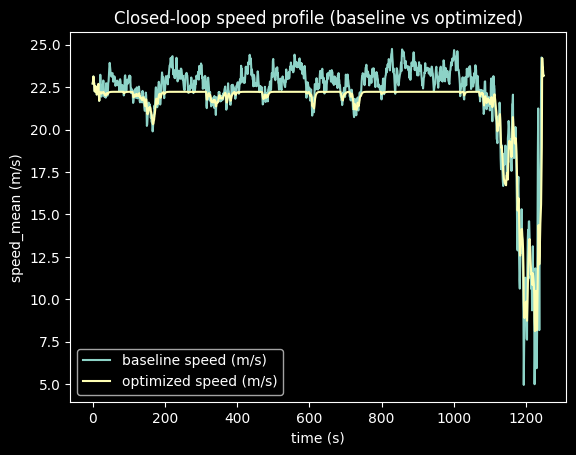

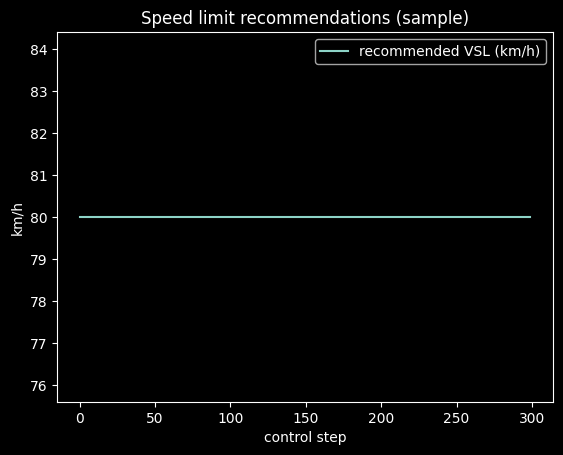

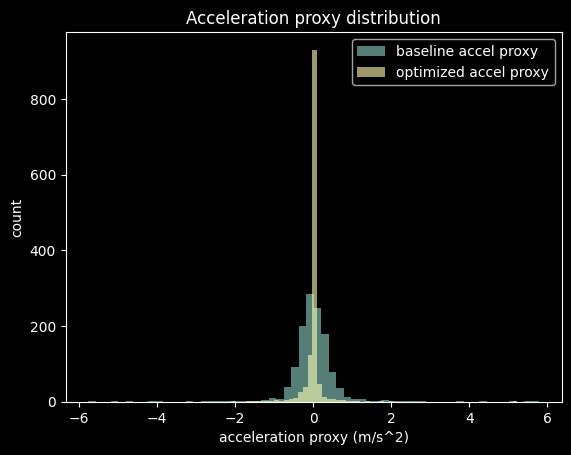

In [11]:
from models.optimizer import choose_speed_limit, VSLConfig
import numpy as np
import torch
import matplotlib.pyplot as plt

DT = 1.0
BRAKE_THR = -2.0

# Use the same values you used in training
SEQ = 20      # seq_len
H = 5         # horizon

cfg_vsl = VSLConfig(candidates_kmh=(60, 80, 100, 120), max_change_kmh=20, risk_thresh=0.5)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()

# pick one lane-segment trajectory from validation (enough length)
g = val_df.groupby(["laneId", "segment"]).filter(lambda x: len(x) > (SEQ + H + 200))

laneId, segment = int(g.iloc[0]["laneId"]), int(g.iloc[0]["segment"])
traj = (
    val_df[(val_df["laneId"] == laneId) & (val_df["segment"] == segment)]
    .sort_values("tbin")
    .reset_index(drop=True)
)

v_base = traj["speed_mean"].values.astype(np.float32)

def braking_stats(v, dt=1.0, thr=-2.0):
    a = (v[1:] - v[:-1]) / dt
    events = int((a < thr).sum())
    severity = float(np.sum(np.clip(-a, 0, None)))
    return events, severity, a

feat_cols = feature_cols  # must match training

def make_window(df_window):
    X = df_window[feat_cols].values.astype(np.float32)
    X = (X - train_ds.x_scaler.mu) / train_ds.x_scaler.sig
    return torch.tensor(X, dtype=torch.float32).unsqueeze(0)

limits = []
v_opt = v_base.copy()
current_limit = 100

for t in range(0, len(traj) - (SEQ + H)):
    win = traj.iloc[t : t + SEQ]
    X = make_window(win).to(device)

    with torch.no_grad():
        pred_speed, lc_logits = model(X)
        pred_speed = float(pred_speed.cpu().numpy()[0])       # m/s
        lc_risk = float(torch.sigmoid(lc_logits).cpu().numpy()[0])

    current_limit = choose_speed_limit(current_limit, pred_speed, lc_risk, cfg=cfg_vsl)
    limits.append(current_limit)

    cap = current_limit / 3.6
    nxt = t + SEQ
    if nxt < len(v_opt):
        v_opt[nxt] = min(v_opt[nxt], cap)
        if nxt - 1 >= 0:
            v_opt[nxt] = 0.7 * v_opt[nxt - 1] + 0.3 * v_opt[nxt]

base_events, base_sev, a_base = braking_stats(v_base, dt=DT, thr=BRAKE_THR)
opt_events, opt_sev, a_opt = braking_stats(v_opt, dt=DT, thr=BRAKE_THR)

print(f"Lane={laneId}, Segment={segment}, points={len(v_base)}")
print("Baseline hard braking events:", base_events, "| severity:", round(base_sev, 2))
print("Optimized hard braking events:", opt_events, "| severity:", round(opt_sev, 2))
print("Reduction (%):", round(100 * (base_events - opt_events) / max(1, base_events), 2))
print("Speed variance baseline:", float(np.var(v_base)))
print("Speed variance optimized:", float(np.var(v_opt)))

T = np.arange(len(v_base)) * DT

plt.figure()
plt.plot(T, v_base, label="baseline speed (m/s)")
plt.plot(T, v_opt, label="optimized speed (m/s)")
plt.xlabel("time (s)")
plt.ylabel("speed_mean (m/s)")
plt.title("Closed-loop speed profile (baseline vs optimized)")
plt.legend()
plt.show()

plt.figure()
plt.plot(limits[:300], label="recommended VSL (km/h)")
plt.xlabel("control step")
plt.ylabel("km/h")
plt.title("Speed limit recommendations (sample)")
plt.legend()
plt.show()

plt.figure()
plt.hist(a_base, bins=60, alpha=0.6, label="baseline accel proxy")
plt.hist(a_opt, bins=60, alpha=0.6, label="optimized accel proxy")
plt.xlabel("acceleration proxy (m/s^2)")
plt.ylabel("count")
plt.title("Acceleration proxy distribution")
plt.legend()
plt.show()
